
<h1 style="text-align: center; font-family: 'Helvetica Neue', Arial, sans-serif; color: #1a365d; font-weight: bold; letter-spacing: 1px;">
    TS4
</h1>



<div style="text-align: center; font-family: 'Segoe UI', Helvetica, Arial, sans-serif; font-size: 16px;">
<b>Nombre y apellido:</b> Irina Polack



</div>


$$\textbf{Introducción:}$$

En este trabajo vamos a analizar las distintas formas de ventaneo de una señal con 4 tipos de ventanas distintas:
    
    *Rectangular
    
    *Flattop 
    
    *Blackmanharris
    
    *Triangular

con la siguiente señal:
    $x[n]=a0⋅sen(Ω1⋅n)+na(n)$

siendo $a0=\sqrt{2}$

$Ω1=Ω0+\frac{2π}{N}$
$Ω0=\frac{π}{2}$

siendo la variable aleatoria definida por la siguiente distribución de probabilidad:

$fr∼U(−2,2)$


na el ruido dado por: 

$na∼N(0,σ2)$

Vamos a dividir en 2 casos, SNR=3 dB y SNR= 10 dB

Lo que se va a hacer en un principio es 200 realizaciones de fr entre -2 a 2, lo que va a pasar (como se vio en la TS3 previamente) es que cuando Ω1 caiga en una frecuencia que no cae en un bin vamos a ver el fenómeno de spectral leakage, mientras que cuando caiga exactamente en un bin, vamos a ver el total de la energía/2, al estar fr entre -2 y 2, y $Ω0=\frac{π}{2}$, ff va a estar ubicada en N/4=250 Hz, y cuando fr sea {-2, -1, 0, 1, 2} la energía se va a encontrar concentrada en {248, 249, 250, 251, 252} Hz, en el resto se va a desparramar

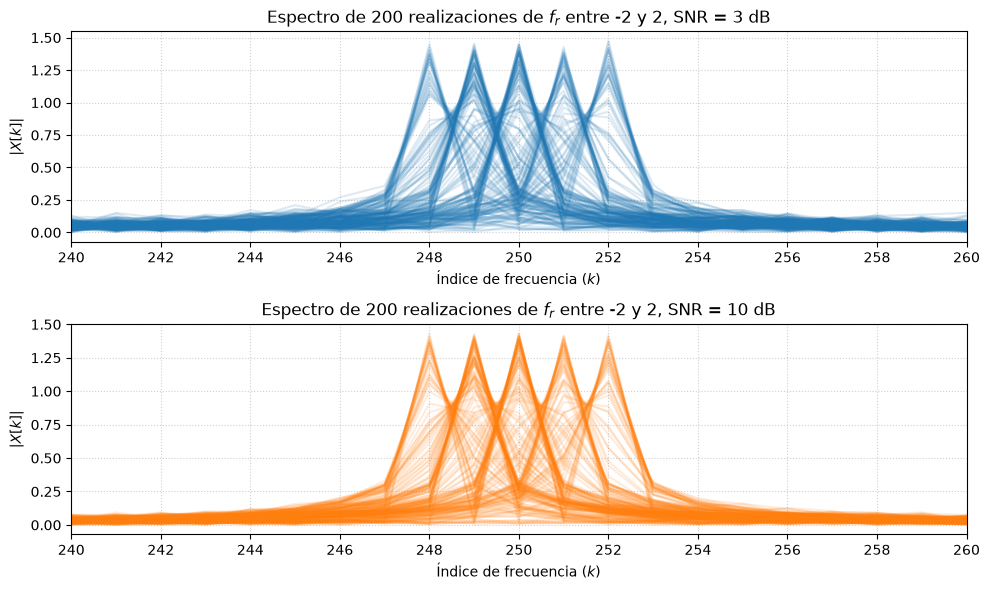

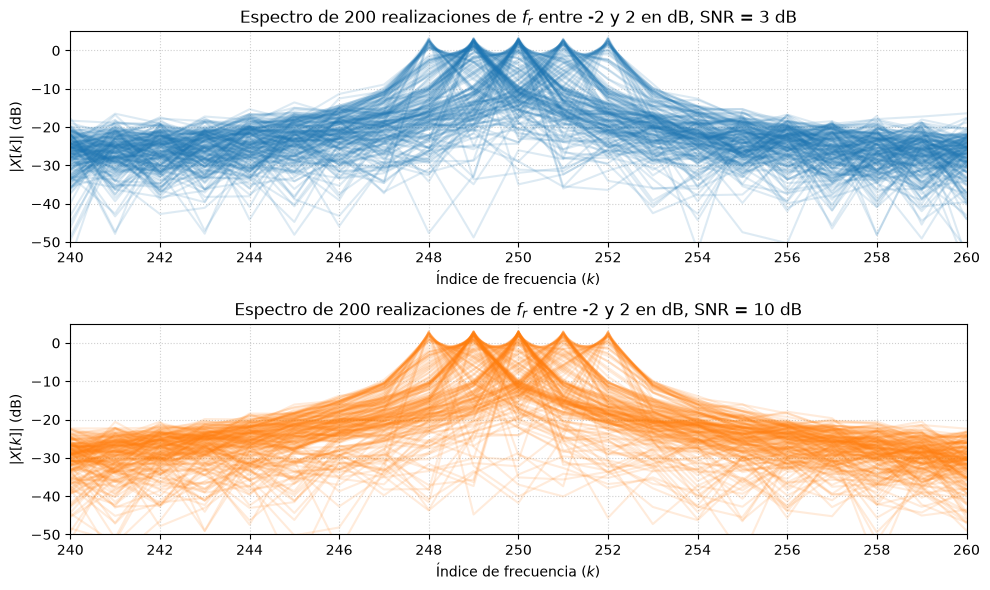

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal.windows as ssw

A = np.sqrt(2)                     
Ps = 1        
SNR1 = 3 # dB
SNR2 = 10
Pruido1 = Ps / (10 ** (SNR1 / 10))
Pruido2 = Ps / (10 ** (SNR2 / 10))
N = 1000
nn = np.arange(N)
fs = 1000
R = 200
a = np.arange(R)
b = np.arange(R/50)
fr = np.random.uniform(-2, 2, R)
na1 = np.random.normal(0, np.sqrt(Pruido1), (N, R))
na2 = np.random.normal(0, np.sqrt(Pruido2), (N, R))
nn_r = nn.reshape(N, 1)
fr_r = fr.reshape(1, R)

omega0 = np.pi / 2
nn_r = nn.reshape(N, 1) 
omega1 = omega0 + fr * (2 * np.pi / N)
omega_1_r = omega1.reshape(1, R)


s = A * np.sin(nn_r * omega_1_r)

s_r1 = s + na1
s_r2 = s + na2
fft_s_r1 = np.fft.fft(s_r1, axis=0)
fft_s_r2 = np.fft.fft(s_r2, axis=0)

w_rect = ssw.get_window('boxcar', N)
w_flat = ssw.get_window('flattop', N)
w_bmh = ssw.get_window('blackmanharris', N)
w_tri = ssw.get_window('triang', N)

fft_w_rect1 = np.fft.fft(s_r1 * w_rect[:, None], axis=0)
fft_w_flat1 = np.fft.fft(s_r1 * w_flat[:, None], axis=0)
fft_w_bmh1 = np.fft.fft(s_r1 * w_bmh[:, None], axis=0)
fft_w_tri1 = np.fft.fft(s_r1 * w_tri[:, None], axis=0)

fft_w_rect2 = np.fft.fft(s_r2 * w_rect[:, None], axis=0)
fft_w_flat2 = np.fft.fft(s_r2 * w_flat[:, None], axis=0)
fft_w_bmh2 = np.fft.fft(s_r2 * w_bmh[:, None], axis=0)
fft_w_tri2 = np.fft.fft(s_r2 * w_tri[:, None], axis=0)


k_min, k_max = 240, 260
bins_eje = np.arange(k_min, k_max + 1, 2)


plt.figure(1, figsize=(10, 6))

plt.subplot(2, 1, 1)
for r in a:
    plt.plot((2/N) * np.abs(fft_s_r1[:, r]), color='tab:blue', alpha=0.15)

plt.title("Espectro de 200 realizaciones de $f_r$ entre -2 y 2, SNR = 3 dB")
plt.xlabel("Índice de frecuencia ($k$)")
plt.ylabel("$|X[k]|$")
plt.xticks(bins_eje)
plt.xlim(k_min, k_max)
plt.grid(True, linestyle=':', alpha=0.6)

plt.subplot(2, 1, 2)
for r in a:
    plt.plot((2/N) * np.abs(fft_s_r2[:, r]), color='tab:orange', alpha=0.15)

plt.title("Espectro de 200 realizaciones de $f_r$ entre -2 y 2, SNR = 10 dB")
plt.xlabel("Índice de frecuencia ($k$)")
plt.ylabel("$|X[k]|$")
plt.xticks(bins_eje)
plt.xlim(k_min, k_max)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


plt.figure(2, figsize=(10, 6))

plt.subplot(2, 1, 1)
for r in a:
    mag_norm1 = (2/N) * np.abs(fft_s_r1[:, r])
    plt.plot(20 * np.log10(mag_norm1 + 1e-12), color='tab:blue', alpha=0.15)

plt.title("Espectro de 200 realizaciones de $f_r$ entre -2 y 2 en dB, SNR = 3 dB")
plt.xlabel("Índice de frecuencia ($k$)")
plt.ylabel("$|X[k]|$ (dB)")
plt.xticks(bins_eje)
plt.xlim(k_min, k_max)
plt.ylim(-50, 5)
plt.grid(True, linestyle=':', alpha=0.6)

plt.subplot(2, 1, 2)
for r in a:
    mag_norm2 = (2/N) * np.abs(fft_s_r2[:, r])
    plt.plot(20 * np.log10(mag_norm2 + 1e-12), color='tab:orange', alpha=0.15)

plt.title("Espectro de 200 realizaciones de $f_r$ entre -2 y 2 en dB, SNR = 10 dB")
plt.xlabel("Índice de frecuencia ($k$)")
plt.ylabel("$|X[k]|$ (dB)")
plt.xticks(bins_eje)
plt.xlim(k_min, k_max)
plt.ylim(-50, 5)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

$$\textbf{Análisis:}$$

En este caso usamos solo la ventana implícita u[n], la cual es igual a 1 entre 0 y N-1 e igual a 0 en el resto.
Se puede observar lo dicho previamente, picos definidos en k={248, 249, 250, 251, 252} y en el resto desparrame espectral.
En el caso de SNR=3dB se ve un mayor piso de ruido que en el caso de SNR=10dB, pero no es nada muy significativo.

$$\textbf{Ventaneo:}$$


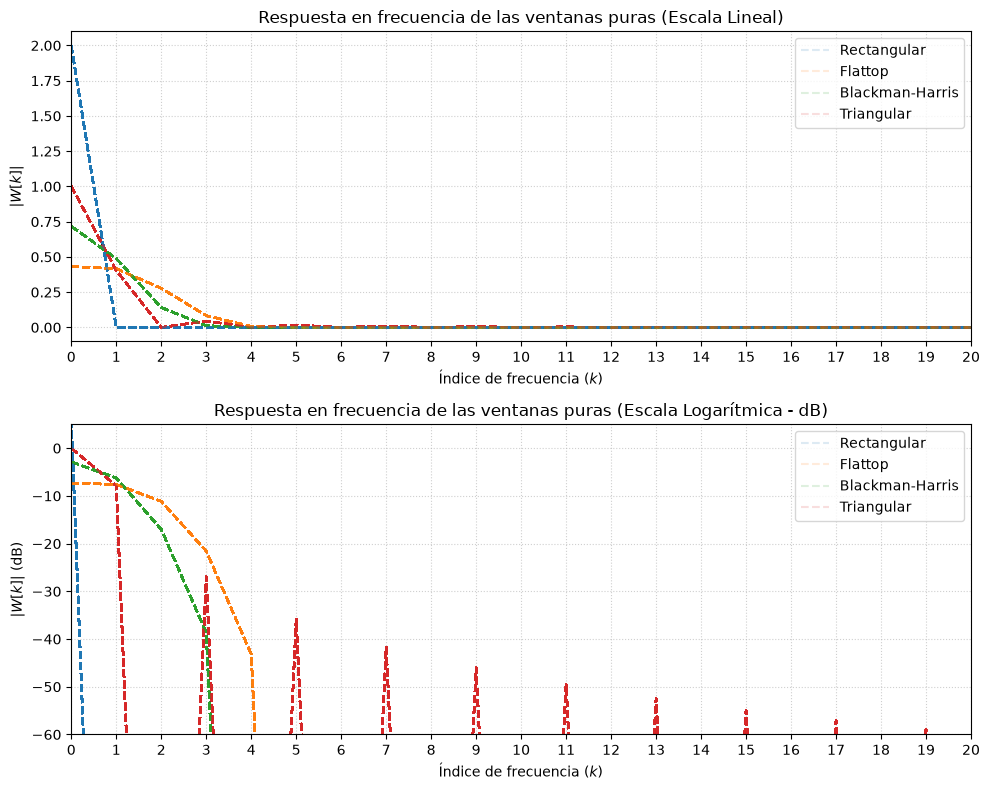

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal.windows as ssw

N = 1000
R = 200
a = np.arange(R)
ticks_k = np.arange(0, 20 + 1, 1)

w_rect3 = ssw.get_window('boxcar', N)
w_flat3 = ssw.get_window('flattop', N)
w_bmh3 = ssw.get_window('blackmanharris', N)
w_tri3 = ssw.get_window('triang', N)


fft_w_rect3 = np.fft.fft(w_rect3[:, None], axis=0)
fft_w_flat3 = np.fft.fft(w_flat3[:, None], axis=0)
fft_w_bmh3 = np.fft.fft(w_bmh3[:, None], axis=0)
fft_w_tri3 = np.fft.fft(w_tri3[:, None], axis=0)


plt.figure(2, figsize=(10, 8))


plt.subplot(2, 1, 1)
for r in a:
    lbl1 = "Rectangular" if r == 0 else ""
    lbl2 = "Flattop" if r == 0 else ""
    lbl3 = "Blackman-Harris" if r == 0 else ""
    lbl4 = "Triangular" if r == 0 else ""

    plt.plot((2/N) * np.abs(fft_w_rect3[:, 0]), color='tab:blue', linestyle='--', alpha=0.15, label=lbl1)
    plt.plot((2/N) * np.abs(fft_w_flat3[:, 0]), color='tab:orange', linestyle='--', alpha=0.15, label=lbl2)
    plt.plot((2/N) * np.abs(fft_w_bmh3[:, 0]), color='tab:green', linestyle='--', alpha=0.15, label=lbl3)
    plt.plot((2/N) * np.abs(fft_w_tri3[:, 0]), color='tab:red', linestyle='--', alpha=0.15, label=lbl4)

plt.xlim(0, 20)
plt.xticks(ticks_k)
plt.xlabel("Índice de frecuencia ($k$)")
plt.ylabel("$|W[k]|$")
plt.title("Respuesta en frecuencia de las ventanas puras (Escala Lineal)")
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')


plt.subplot(2, 1, 2)
for r in a:
    lbl1 = "Rectangular" if r == 0 else ""
    lbl2 = "Flattop" if r == 0 else ""
    lbl3 = "Blackman-Harris" if r == 0 else ""
    lbl4 = "Triangular" if r == 0 else ""

    plt.plot(20 * np.log10((2/N) * np.abs(fft_w_rect3[:, 0]) + 1e-12), color='tab:blue', linestyle='--', alpha=0.15, label=lbl1)
    plt.plot(20 * np.log10((2/N) * np.abs(fft_w_flat3[:, 0]) + 1e-12), color='tab:orange', linestyle='--', alpha=0.15, label=lbl2)
    plt.plot(20 * np.log10((2/N) * np.abs(fft_w_bmh3[:, 0]) + 1e-12), color='tab:green', linestyle='--', alpha=0.15, label=lbl3)
    plt.plot(20 * np.log10((2/N) * np.abs(fft_w_tri3[:, 0]) + 1e-12), color='tab:red', linestyle='--', alpha=0.15, label=lbl4)

plt.xlim(0, 20)
plt.xticks(ticks_k)
plt.ylim(-60, 5)
plt.xlabel("Índice de frecuencia ($k$)")
plt.ylabel("$|W[k]|$ (dB)")
plt.title("Respuesta en frecuencia de las ventanas puras (Escala Logarítmica - dB)")
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

$$\textbf{Análisis:}$$
Antes de pasar a la señal ventaneada, quería observar como se veía cada una.
se puede ver que el ancho del lóbulo principal de la rectangular es el más chico, pero también es el más alto, así como la triangular tiene la mitad de altura pero el doble de ancho, y así se ve con cada ventana (si pierden alto sus lóbulos principales aumentan ancho).
Si multiplicamos la señal senoidal con cada una de estas ventanas, lo más probable es que la rectangular me conserve toda la energía gracias a su altura (es como multiplicar por 1), en cambio. como las demás son más bajas que la señal, lo más probable es que me dispersen esta energía, disminuyendo la altura de los picos y aumentando el ancho.


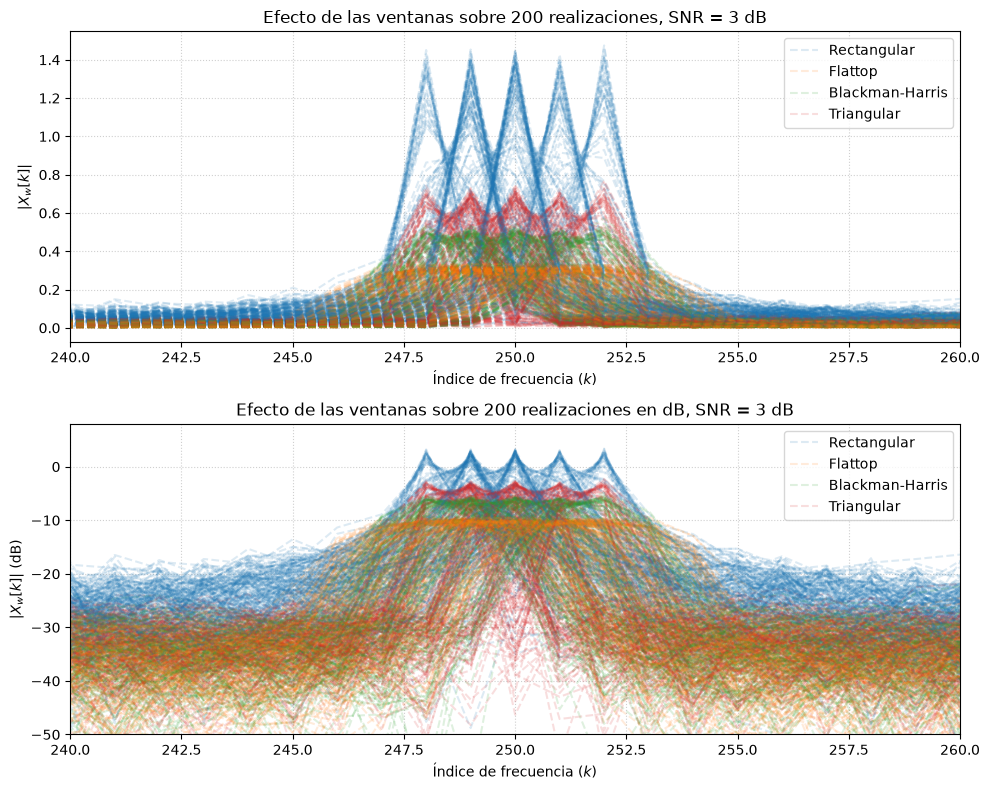

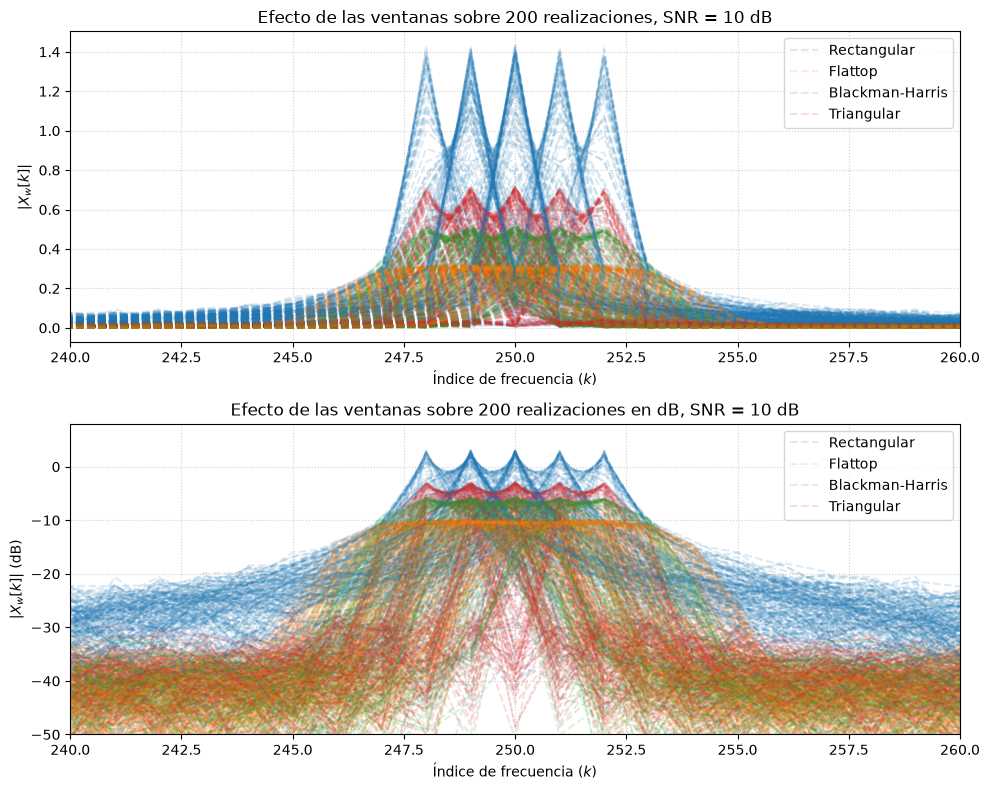

In [6]:

plt.figure(2, figsize=(10, 8))

# Subplot 1: Escala Lineal
plt.subplot(2, 1, 1)
for r in a:
    lbl1 = "Rectangular" if r == 0 else ""
    lbl2 = "Flattop" if r == 0 else ""
    lbl3 = "Blackman-Harris" if r == 0 else ""
    lbl4 = "Triangular" if r == 0 else ""

    plt.plot((2/N) * np.abs(fft_w_rect1[:, r]), color='tab:blue', linestyle='--', alpha=0.15, label=lbl1)
    plt.plot((2/N) * np.abs(fft_w_flat1[:, r]), color='tab:orange', linestyle='--', alpha=0.15, label=lbl2)
    plt.plot((2/N) * np.abs(fft_w_bmh1[:, r]), color='tab:green', linestyle='--', alpha=0.15, label=lbl3)
    plt.plot((2/N) * np.abs(fft_w_tri1[:, r]), color='tab:red', linestyle='--', alpha=0.15, label=lbl4)

plt.xlim(240, 260)
plt.xlabel("Índice de frecuencia ($k$)")
plt.ylabel("$|X_w[k]|$")
plt.title("Efecto de las ventanas sobre 200 realizaciones, SNR = 3 dB")
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')

# Subplot 2: Escala Decibeles (dB)
plt.subplot(2, 1, 2)
for r in a:
    lbl1 = "Rectangular" if r == 0 else ""
    lbl2 = "Flattop" if r == 0 else ""
    lbl3 = "Blackman-Harris" if r == 0 else ""
    lbl4 = "Triangular" if r == 0 else ""

    plt.plot(20 * np.log10((2/N) * np.abs(fft_w_rect1[:, r]) + 1e-12), color='tab:blue', linestyle='--', alpha=0.15, label=lbl1)
    plt.plot(20 * np.log10((2/N) * np.abs(fft_w_flat1[:, r]) + 1e-12), color='tab:orange', linestyle='--', alpha=0.15, label=lbl2)
    plt.plot(20 * np.log10((2/N) * np.abs(fft_w_bmh1[:, r]) + 1e-12), color='tab:green', linestyle='--', alpha=0.15, label=lbl3)
    plt.plot(20 * np.log10((2/N) * np.abs(fft_w_tri1[:, r]) + 1e-12), color='tab:red', linestyle='--', alpha=0.15, label=lbl4)

plt.xlim(240, 260)
plt.ylim(-50, 8)
plt.xlabel("Índice de frecuencia ($k$)")
plt.ylabel("$|X_w[k]|$ (dB)")
plt.title("Efecto de las ventanas sobre 200 realizaciones en dB, SNR = 3 dB")
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()


plt.figure(3, figsize=(10, 8))

# Subplot 1: Escala Lineal
plt.subplot(2, 1, 1)
for r in a:
    lbl1 = "Rectangular" if r == 0 else ""
    lbl2 = "Flattop" if r == 0 else ""
    lbl3 = "Blackman-Harris" if r == 0 else ""
    lbl4 = "Triangular" if r == 0 else ""

    plt.plot((2/N) * np.abs(fft_w_rect2[:, r]), color='tab:blue', linestyle='--', alpha=0.15, label=lbl1)
    plt.plot((2/N) * np.abs(fft_w_flat2[:, r]), color='tab:orange', linestyle='--', alpha=0.15, label=lbl2)
    plt.plot((2/N) * np.abs(fft_w_bmh2[:, r]), color='tab:green', linestyle='--', alpha=0.15, label=lbl3)
    plt.plot((2/N) * np.abs(fft_w_tri2[:, r]), color='tab:red', linestyle='--', alpha=0.15, label=lbl4)

plt.xlim(240, 260)
plt.xlabel("Índice de frecuencia ($k$)")
plt.ylabel("$|X_w[k]|$")
plt.title("Efecto de las ventanas sobre 200 realizaciones, SNR = 10 dB")
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')

# Subplot 2: Escala Decibeles (dB)
plt.subplot(2, 1, 2)
for r in a:
    lbl1 = "Rectangular" if r == 0 else ""
    lbl2 = "Flattop" if r == 0 else ""
    lbl3 = "Blackman-Harris" if r == 0 else ""
    lbl4 = "Triangular" if r == 0 else ""

    plt.plot(20 * np.log10((2/N) * np.abs(fft_w_rect2[:, r]) + 1e-12), color='tab:blue', linestyle='--', alpha=0.15, label=lbl1)
    plt.plot(20 * np.log10((2/N) * np.abs(fft_w_flat2[:, r]) + 1e-12), color='tab:orange', linestyle='--', alpha=0.15, label=lbl2)
    plt.plot(20 * np.log10((2/N) * np.abs(fft_w_bmh2[:, r]) + 1e-12), color='tab:green', linestyle='--', alpha=0.15, label=lbl3)
    plt.plot(20 * np.log10((2/N) * np.abs(fft_w_tri2[:, r]) + 1e-12), color='tab:red', linestyle='--', alpha=0.15, label=lbl4)

plt.xlim(240, 260)
plt.ylim(-50, 8)
plt.xlabel("Índice de frecuencia ($k$)")
plt.ylabel("$|X_w[k]|$ (dB)")
plt.title("Efecto de las ventanas sobre 200 realizaciones en dB, SNR = 10 dB")
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

$$\textbf{Análisis:}$$

Se puede observar que la ventana rectangular deja  a las deltas de la misma altura que antes, mientras que la triangular, blackman-Hariis y flattop les baja la altura en ese orden. En el caso de la triangular y Blackman-Harris se pueden todavía apreciar un poco los picos, mientras que ya en el caso de Flattop no, esto a causa de que la flattop tiene el lóbulo más ancho, vease que la flattop a diferencia de la rectangular, al aplanarme el espectro, disminuye el fenómeno de spectral leakage, mientras que en la rectangular se puede observar este fenómeno, (se observan las diferentes alturas, cuando cae el pico en un bin y cuando no), al haber spectral leakage, se ve una mezcla de las deltas y por lo tanto no se pueden apreciar bien los picos ya que se están intersectando las líneas.
Se puede ver que el ventaneo me disminuyo energía, (a menor altura, menor energía).
Además se ve el piso de ruido por fuera de donde está concentrada toda la energía, (aproximadamente entre 248 Hz y 252 Hz) casi 10 dB por debajo del de la rectangular.
Eso me muestra que al aumentar el ancho de la ventana, disminuyo la energía pero también disminuyo ruido, en cambio la ventana rectangular me mantiene la energía cuando la delta cae en un bin definido pero da como resultado esparcir el ruido por el resto de frecuencias, dando un piso de ruido muy elevado.

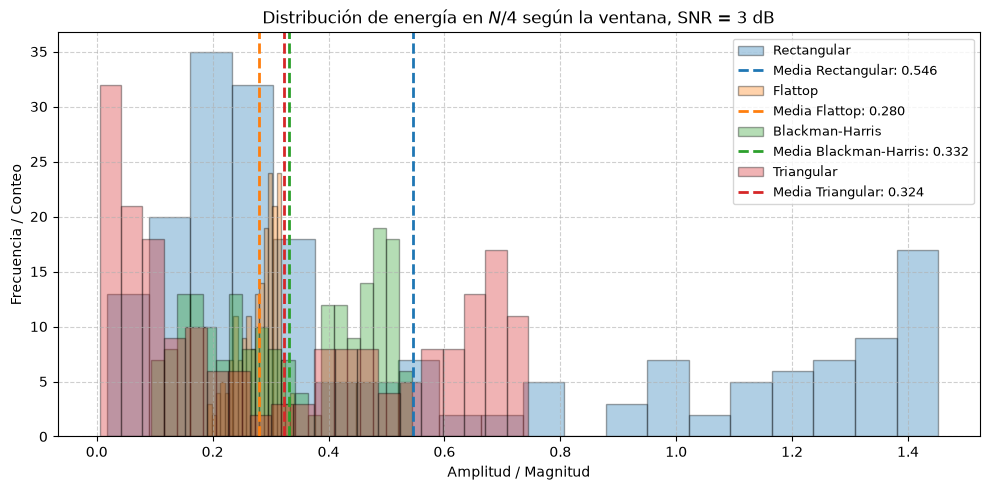

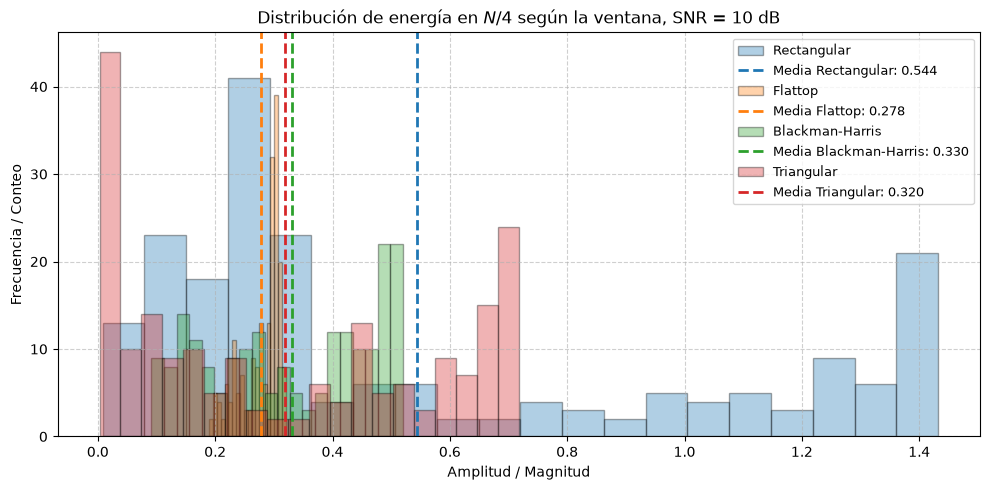

In [7]:
import numpy as np
import matplotlib.pyplot as plt


a1w0_1 = 2 * (1/N) * fft_w_rect1[N // 4, :]
a1w1_1 = 2 * (1/N) * fft_w_flat1[N // 4, :]
a1w2_1 = 2 * (1/N) * fft_w_bmh1[N // 4, :]
a1w3_1 = 2 * (1/N) * fft_w_tri1[N // 4, :]

data_1 = {
    'Rectangular': np.abs(a1w0_1),
    'Flattop': np.abs(a1w1_1),
    'Blackman-Harris': np.abs(a1w2_1),
    'Triangular': np.abs(a1w3_1)
}

plt.figure(figsize=(10, 5))
bins = 20
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']

for (label, values), color in zip(data_1.items(), colors):
    mean_val = np.mean(values)
    
    # Histograma
    plt.hist(
        values,
        bins=bins,
        alpha=0.35,
        edgecolor='black',
        color=color,
        label=f'{label}'
    )
    # Línea vertical indicando la media de cada ventana
    plt.axvline(
        mean_val,
        color=color,
        linestyle='--',
        linewidth=2,
        label=f'Media {label}: {mean_val:.3f}'
    )

plt.xlabel('Amplitud / Magnitud')
plt.ylabel('Frecuencia / Conteo')
plt.title('Distribución de energía en $N/4$ según la ventana, SNR = 3 dB')
plt.legend(loc='upper right', fontsize=9)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


a1w0_2 = 2 * (1/N) * fft_w_rect2[N // 4, :]
a1w1_2 = 2 * (1/N) * fft_w_flat2[N // 4, :]
a1w2_2 = 2 * (1/N) * fft_w_bmh2[N // 4, :]
a1w3_2 = 2 * (1/N) * fft_w_tri2[N // 4, :]

data_2 = {
    'Rectangular': np.abs(a1w0_2),
    'Flattop': np.abs(a1w1_2),
    'Blackman-Harris': np.abs(a1w2_2),
    'Triangular': np.abs(a1w3_2)
}

plt.figure(figsize=(10, 5))

for (label, values), color in zip(data_2.items(), colors):
    mean_val = np.mean(values)
    
    # Histograma
    plt.hist(
        values,
        bins=bins,
        alpha=0.35,
        edgecolor='black',
        color=color,
        label=f'{label}'
    )
    # Línea vertical indicando la media de cada ventana
    plt.axvline(
        mean_val,
        color=color,
        linestyle='--',
        linewidth=2,
        label=f'Media {label}: {mean_val:.3f}'
    )

plt.xlabel('Amplitud / Magnitud')
plt.ylabel('Frecuencia / Conteo')
plt.title('Distribución de energía en $N/4$ según la ventana, SNR = 10 dB')
plt.legend(loc='upper right', fontsize=9)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

$$\textbf{Análisis:}$$
En ambas distribuciones se puede ver que la flattop tiene un pico más fino que el resto en aproximadamente 0.3, que sea más fino que el resto significa que una gran parte de las frecuencias coinciden en un valor específico, en este caso aproximadamente 0.3, mientras que los otros casos tienen barras más anchas, eso quiere decir que la energía varía en un rango más ancho. 
Sabemos que la energía de la señal es 1.4, veamos que la ventana que tiene una media más cercana a éste es la rectángular, la cual tiene barras más anchas (mayor varianza), mientras que la flattop es la que tiene el valor medio más alejado de la energía real pero aún así el de menor varianza.
Veamos que la rectangular es la que tiene una distribución más "dispareja" en todas las energías, mientras que la flattop no, sino todo lo contrario.
Esto muestra como la varianza en el caso de la rectangular no sigue un patrón específico, mientras el sesgo de la flattop si, ya que todos los valores se encuentran muy cerca entre ellos aunque lejos del valor real.
Eso nos hace pensar que el sesgo sigue un patrón específico mientras que la varianza no, por lo tanto, este resultado nos hace creer que es mejor corregir el sesgo que la varianza.


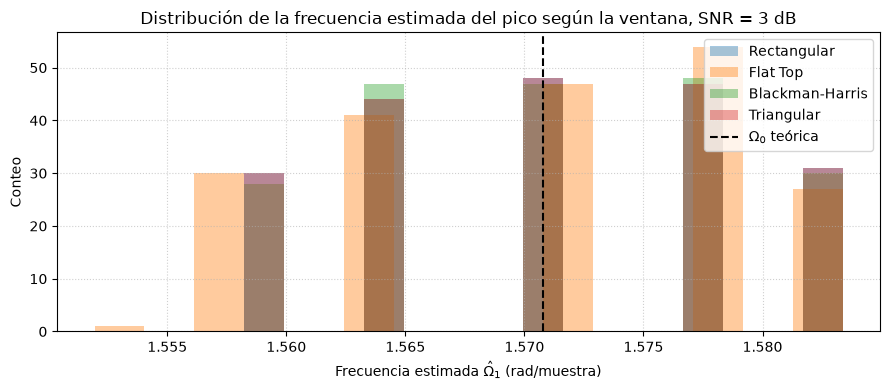

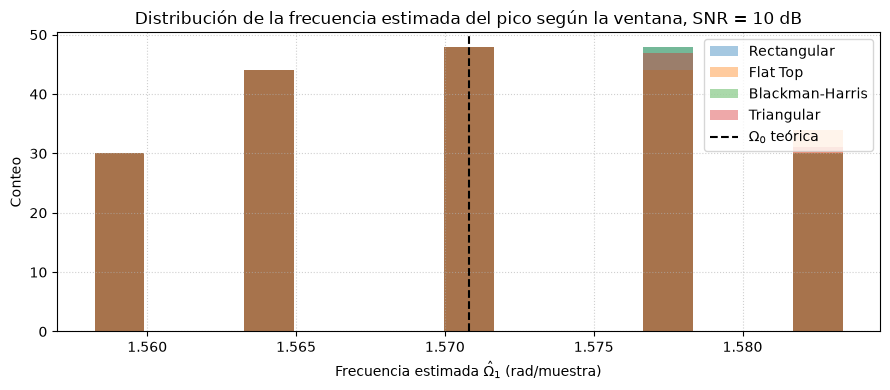

In [23]:
omegas = 2 * np.pi * np.arange(N) / N

# ==========================================
# FIGURA 1: FRECUENCIA ESTIMADA (SNR = 3 dB)
# ==========================================
idx_max_rect1 = np.argmax(np.abs(fft_w_rect1[:N//2, :]), axis=0)
idx_max_flat1 = np.argmax(np.abs(fft_w_flat1[:N//2, :]), axis=0)
idx_max_bmh1  = np.argmax(np.abs(fft_w_bmh1[:N//2, :]),  axis=0)
idx_max_tri1  = np.argmax(np.abs(fft_w_tri1[:N//2, :]),  axis=0)

omega1_hat_rect1 = omegas[idx_max_rect1]
omega1_hat_flat1 = omegas[idx_max_flat1]
omega1_hat_bmh1  = omegas[idx_max_bmh1]
omega1_hat_tri1  = omegas[idx_max_tri1]

plt.figure(figsize=(9, 4))
plt.hist(omega1_hat_rect1, bins=15, alpha=0.4, color='tab:blue', label='Rectangular')
plt.hist(omega1_hat_flat1, bins=15, alpha=0.4, color='tab:orange', label='Flat Top')
plt.hist(omega1_hat_bmh1,  bins=15, alpha=0.4, color='tab:green', label='Blackman-Harris')
plt.hist(omega1_hat_tri1,  bins=15, alpha=0.4, color='tab:red', label='Triangular')

plt.axvline(omega0, color='black', linestyle='--', label='$\Omega_0$ teórica')
plt.xlabel('Frecuencia estimada $\hat{\Omega}_1$ (rad/muestra)')
plt.ylabel('Conteo')
plt.title('Distribución de la frecuencia estimada del pico según la ventana, SNR = 3 dB')
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# ==========================================
# FIGURA 2: FRECUENCIA ESTIMADA (SNR = 10 dB)
# ==========================================
idx_max_rect2 = np.argmax(np.abs(fft_w_rect2[:N//2, :]), axis=0)
idx_max_flat2 = np.argmax(np.abs(fft_w_flat2[:N//2, :]), axis=0)
idx_max_bmh2  = np.argmax(np.abs(fft_w_bmh2[:N//2, :]),  axis=0)
idx_max_tri2  = np.argmax(np.abs(fft_w_tri2[:N//2, :]),  axis=0)

omega1_hat_rect2 = omegas[idx_max_rect2]
omega1_hat_flat2 = omegas[idx_max_flat2]
omega1_hat_bmh2  = omegas[idx_max_bmh2]
omega1_hat_tri2  = omegas[idx_max_tri2]

plt.figure(figsize=(9, 4))
plt.hist(omega1_hat_rect2, bins=15, alpha=0.4, color='tab:blue', label='Rectangular')
plt.hist(omega1_hat_flat2, bins=15, alpha=0.4, color='tab:orange', label='Flat Top')
plt.hist(omega1_hat_bmh2,  bins=15, alpha=0.4, color='tab:green', label='Blackman-Harris')
plt.hist(omega1_hat_tri2,  bins=15, alpha=0.4, color='tab:red', label='Triangular')

plt.axvline(omega0, color='black', linestyle='--', label='$\Omega_0$ teórica')
plt.xlabel('Frecuencia estimada $\hat{\Omega}_1$ (rad/muestra)')
plt.ylabel('Conteo')
plt.title('Distribución de la frecuencia estimada del pico según la ventana, SNR = 10 dB')
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

$$\textbf{Análisis:}$$
Se  puede ver que los picos máximos caen en:


$\frac{2π \dot 248}{1000}≈1.558, fr=-2$


$\frac{2π \dot 249}{1000}≈1.565, fr=-1$


$\frac{2π \dot 250}{1000}≈1.570, fr=0$


$\frac{2π \dot 251}{1000}≈1.577, fr=1$



$\frac{2π \dot 252}{1000}≈1.583, fr=2$

eso significa que los máximos suceden cuando caen exactamente en un bin, que es lo que observamos al principio.
Se puede ver que hay una mayor disperción en el caso de SNR=3dB que en el caso de SNR=10dB, eso muestra que a mayor ruido hay una mayor disperción (no me deja observar bien los máximos).





In [8]:
import numpy as np
import pandas as pd


A_real = np.sqrt(2)              
omega_real = np.pi / 2           


omegas = 2 * np.pi * np.arange(N) / N


def calcular_tablas_estimadores(fft_rect, fft_flat, fft_bmh, fft_tri, snr_label):

    amp_rect = 2 * (1/N) * np.abs(fft_rect[N // 4, :])
    amp_flat = 2 * (1/N) * np.abs(fft_flat[N // 4, :])
    amp_bmh  = 2 * (1/N) * np.abs(fft_bmh[N // 4, :])
    amp_tri  = 2 * (1/N) * np.abs(fft_tri[N // 4, :])


    s_a_rect, v_a_rect = np.mean(amp_rect) - A_real, np.var(amp_rect)
    s_a_flat, v_a_flat = np.mean(amp_flat) - A_real, np.var(amp_flat)
    s_a_bmh,  v_a_bmh  = np.mean(amp_bmh)  - A_real, np.var(amp_bmh)
    s_a_tri,  v_a_tri  = np.mean(amp_tri)  - A_real, np.var(amp_tri)

    df_amplitud = pd.DataFrame({
        '$s_a$ (Sesgo)': [s_a_rect, s_a_flat, s_a_bmh, s_a_tri],
        '$v_a$ (Varianza)': [v_a_rect, v_a_flat, v_a_bmh, v_a_tri]
    }, index=['Rectangular', 'Flat-top', 'Blackman-Harris', 'Triangular'])

    # --- ESTIMACIÓN DE FRECUENCIA (argmax) ---
    freq_rect = omegas[np.argmax(np.abs(fft_rect), axis=0)]
    freq_flat = omegas[np.argmax(np.abs(fft_flat), axis=0)]
    freq_bmh  = omegas[np.argmax(np.abs(fft_bmh),  axis=0)]
    freq_tri  = omegas[np.argmax(np.abs(fft_tri),  axis=0)]


    s_f_rect, v_f_rect = np.mean(freq_rect) - omega_real, np.var(freq_rect)
    s_f_flat, v_f_flat = np.mean(freq_flat) - omega_real, np.var(freq_flat)
    s_f_bmh,  v_f_bmh  = np.mean(freq_bmh)  - omega_real, np.var(freq_bmh)
    s_f_tri,  v_f_tri  = np.mean(freq_tri)  - omega_real, np.var(freq_tri)

    df_frecuencia = pd.DataFrame({
        '$s_f$ (Sesgo)': [s_f_rect, s_f_flat, s_f_bmh, s_f_tri],
        '$v_f$ (Varianza)': [v_f_rect, v_f_flat, v_f_bmh, v_f_tri]
    }, index=['Rectangular', 'Flat-top', 'Blackman-Harris', 'Triangular'])

    print(f"\n================ TABLAS SNR = {snr_label} ================")
    print("\n--- Estimación de Amplitud ---")
    print(df_amplitud)
    print("\n--- Estimación de Frecuencia ---")
    print(df_frecuencia)
    
    return df_amplitud, df_frecuencia

df_amp_3dB, df_freq_3dB   = calcular_tablas_estimadores(fft_w_rect1, fft_w_flat1, fft_w_bmh1, fft_w_tri1, "3 dB")
df_amp_10dB, df_freq_10dB = calcular_tablas_estimadores(fft_w_rect2, fft_w_flat2, fft_w_bmh2, fft_w_tri2, "10 dB")


================ TABLAS SNR = 3 dB ================

--- Estimación de Amplitud ---
                 $s_a$ (Sesgo)  $v_a$ (Varianza)
Rectangular          -0.868614          0.215256
Flat-top             -1.134411          0.001117
Blackman-Harris      -1.081953          0.018614
Triangular           -1.090382          0.067194

--- Estimación de Frecuencia ---
                 $s_f$ (Sesgo)  $v_f$ (Varianza)
Rectangular           0.485376          1.291494
Flat-top              0.328359          0.926376
Blackman-Harris       0.438723          1.187944
Triangular            0.438943          1.188540

================ TABLAS SNR = 10 dB ================

--- Estimación de Amplitud ---
                 $s_a$ (Sesgo)  $v_a$ (Varianza)
Rectangular          -0.870515          0.215996
Flat-top             -1.136119          0.001124
Blackman-Harris      -1.083974          0.018854
Triangular           -1.094367          0.068618

--- Estimación de Frecuencia ---
                 $s_f$ (Se

$$\textbf{Análisis:}$$

En la mayoría de los casos a mayor sesgo menor varianza y viceversa, podemos tomarlo como generalizando.
como el sesgo sigue un patrón a diferencia de la varianza nos va a convenir elegir este tipo de ventanas con mayor sesgo y multiplicarlos por un factor de correción (o restarles la media y sumarles la energía) para así poder calibrar y tener un mejor estimador de energía.
En ambos casos me convendría usar la flattop para estimar la energía. 

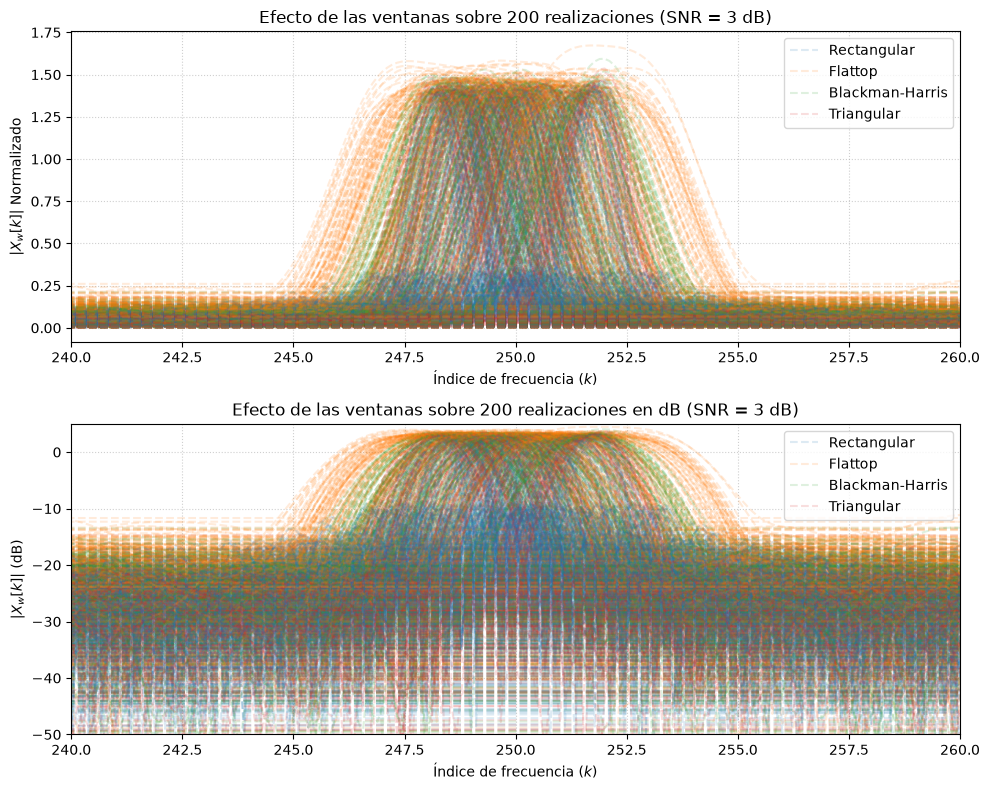

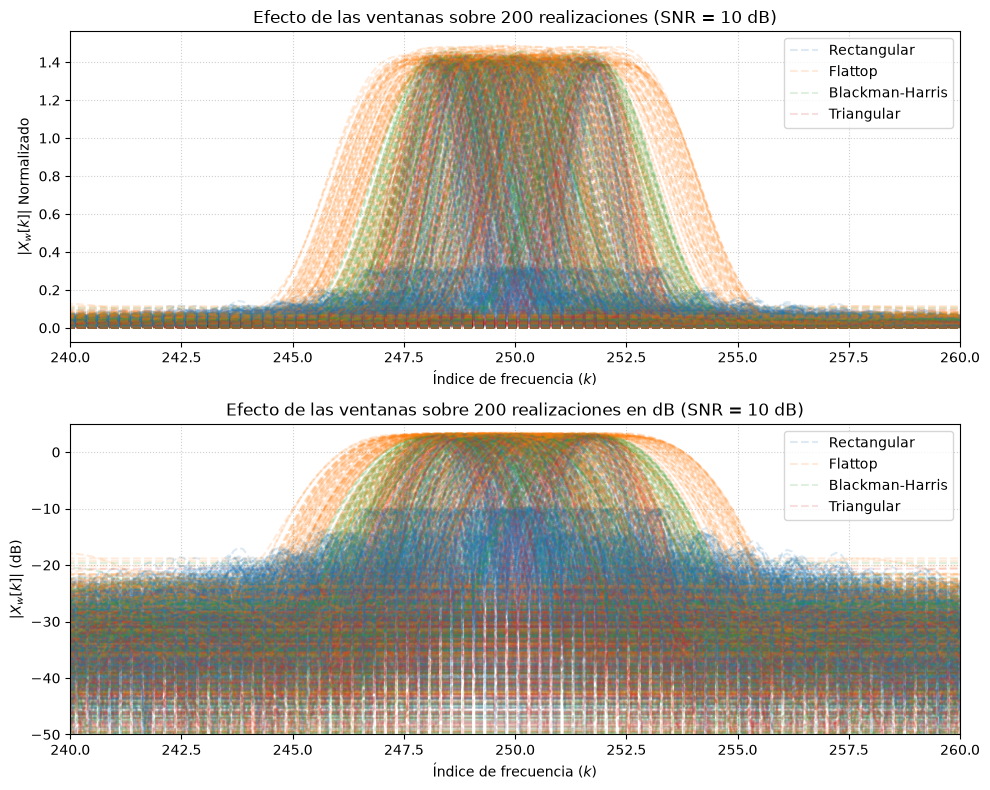

In [12]:
import numpy as np
import matplotlib.pyplot as plt


g_rect = np.sum(w_rect) / 2
g_flat = np.sum(w_flat) / 2
g_bmh  = np.sum(w_bmh)  / 2
g_tri  = np.sum(w_tri)  / 2


# --- Zero-padding: alargamos la FFT (sin alargar la señal) para poder
# interpolar el espectro entre bins y ver mejor la forma de cada lóbulo ---
pad_factor = 9
N_pad = N * pad_factor

fft_w_rect1 = np.fft.fft(s_r1 * w_rect[:, None], n=N_pad, axis=0)
fft_w_flat1 = np.fft.fft(s_r1 * w_flat[:, None], n=N_pad, axis=0)
fft_w_bmh1  = np.fft.fft(s_r1 * w_bmh[:, None],  n=N_pad, axis=0)
fft_w_tri1  = np.fft.fft(s_r1 * w_tri[:, None],  n=N_pad, axis=0)

fft_w_rect2 = np.fft.fft(s_r2 * w_rect[:, None], n=N_pad, axis=0)
fft_w_flat2 = np.fft.fft(s_r2 * w_flat[:, None], n=N_pad, axis=0)
fft_w_bmh2  = np.fft.fft(s_r2 * w_bmh[:, None],  n=N_pad, axis=0)
fft_w_tri2  = np.fft.fft(s_r2 * w_tri[:, None],  n=N_pad, axis=0)


len_fft = fft_w_rect1.shape[0]
k_axis = np.fft.fftfreq(len_fft, d=1/N) if len_fft != N else np.arange(N)


def graficar_comparativa_ventanas(fft_rect, fft_flat, fft_bmh, fft_tri, snr_val, fig_num):
    plt.figure(fig_num, figsize=(10, 8))

   
    plt.subplot(2, 1, 1)
    for r in range(R):
        lbl1 = "Rectangular" if r == 0 else ""
        lbl2 = "Flattop" if r == 0 else ""
        lbl3 = "Blackman-Harris" if r == 0 else ""
        lbl4 = "Triangular" if r == 0 else ""

        plt.plot(k_axis, np.abs(fft_rect[:, r]) / g_rect, color='tab:blue',   linestyle='--', alpha=0.15, label=lbl1)
        plt.plot(k_axis, np.abs(fft_flat[:, r]) / g_flat, color='tab:orange', linestyle='--', alpha=0.15, label=lbl2)
        plt.plot(k_axis, np.abs(fft_bmh[:, r])  / g_bmh,  color='tab:green',  linestyle='--', alpha=0.15, label=lbl3)
        plt.plot(k_axis, np.abs(fft_tri[:, r])  / g_tri,  color='tab:red',    linestyle='--', alpha=0.15, label=lbl4)

    plt.xlim(240, 260)
    plt.xlabel("Índice de frecuencia ($k$)")
    plt.ylabel("$|X_w[k]|$ Normalizado")
    plt.title(f"Efecto de las ventanas sobre 200 realizaciones (SNR = {snr_val} dB)")
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='upper right')

  
    plt.subplot(2, 1, 2)
    for r in range(R):
        lbl1 = "Rectangular" if r == 0 else ""
        lbl2 = "Flattop" if r == 0 else ""
        lbl3 = "Blackman-Harris" if r == 0 else ""
        lbl4 = "Triangular" if r == 0 else ""

        mag_rect_db = 20 * np.log10((np.abs(fft_rect[:, r]) / g_rect) + 1e-12)
        mag_flat_db = 20 * np.log10((np.abs(fft_flat[:, r]) / g_flat) + 1e-12)
        mag_bmh_db  = 20 * np.log10((np.abs(fft_bmh[:, r])  / g_bmh)  + 1e-12)
        mag_tri_db  = 20 * np.log10((np.abs(fft_tri[:, r])  / g_tri)  + 1e-12)

        plt.plot(k_axis, mag_rect_db, color='tab:blue',   linestyle='--', alpha=0.15, label=lbl1)
        plt.plot(k_axis, mag_flat_db, color='tab:orange', linestyle='--', alpha=0.15, label=lbl2)
        plt.plot(k_axis, mag_bmh_db,  color='tab:green',  linestyle='--', alpha=0.15, label=lbl3)
        plt.plot(k_axis, mag_tri_db,  color='tab:red',    linestyle='--', alpha=0.15, label=lbl4)

    plt.xlim(240, 260)
    plt.ylim(-50, 5)
    plt.xlabel("Índice de frecuencia ($k$)")
    plt.ylabel("$|X_w[k]|$ (dB)")
    plt.title(f"Efecto de las ventanas sobre 200 realizaciones en dB (SNR = {snr_val} dB)")
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

# 3. Generar Figura 2 (SNR = 3 dB) y Figura 3 (SNR = 10 dB)
graficar_comparativa_ventanas(fft_w_rect1, fft_w_flat1, fft_w_bmh1, fft_w_tri1, snr_val=3, fig_num=2)
graficar_comparativa_ventanas(fft_w_rect2, fft_w_flat2, fft_w_bmh2, fft_w_tri2, snr_val=10, fig_num=3)

$$\textbf{Análisis:}$$
Ahora se observa como la energía se ve más concentrada entre 248 y 250, que en el caso anterior donde se veía más esparcida la energía en el resto de bins (menos en la rectangular) y como el piso de ruido de las otras ventanas es mucho mayor al de la rectangular.
Aún así, aunque haya zero-padding, las deltas se siguen viendo mejor con la rectangular, podemos observar que al tener dos deltas en frecuencias muy cercanas no es conveniente usar una ventana con lóbulo ancho, ya que ambas van a caer dentro de este lóbulo y en consecuencia no se van a poder distinguir.
En este caso todas las distintas ventanas llegan a la misma altura.

$$\textbf{Conclusión:}$$
En este trabajo se analizó la relación entre varianza y sesgo en las diferentes ventanas, cuales son más sesgadas y cuales tienen una mayor varianza, cual es la mejor elección a la hora de hacer una calibración y una estimación. Dejando como conclusión que la ventana con menos varianza en este caso es la flattop y la de mayor varianza es la rectangular.

También pudimos ver los diferentes ventaneos y como estos afectan a mi señal según el ancho de su lóbulo principal y la diferencia de altura entre el lóbulo principal y los lóbulos secundarios, dejando como conclusión que si dos deltas muy pegadas entre si (una distancia menor a la del ancho del lóbulo principal), no las vamos a poder distinguir, en cambio, si solo tenemos una señal, lo más útil es usar una ventana con un lóbulo principal más ancho, para así poder aislarla bien del espectral leakage que podría haber quedado en el resto de bins (gracias a la diferencia de altura entre el lóbulo principal y los lóbulos secundarios), dejando al descubierto el piso de ruido lejano y poder apreciarla mejor.
Esto nos demuestra que no necesariamente hay una ventana que es la mejor para todos los casos, sino que depende de los factores que quiero analizar, la entrada que tengo y la resolución espectral.